In [3]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan scikit-learn

In [4]:
import numpy as np
import pandas as pd

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

import matplotlib.pyplot as plt

https://mz-moonzoo.tistory.com/23

https://www.sbert.net/docs/sentence_transformer/pretrained_models.html
임베딩 모델 고민

In [5]:
df = pd.read_parquet("df_tokens.parquet")

df["PBSH"] = df["PBSH"].astype(str).str.strip()
df["year"]  = df["PBSH"].str.slice(0, 4).astype("Int64")
df["month"] = df["PBSH"].str.slice(4, 6).astype("Int64")

# year 결측 제거
df = df[df["year"].notna()].copy()

print(df["year"].value_counts().sort_index())

year
2021    12435
2022    12333
2023    12203
2024    12658
2025    11078
Name: count, dtype: Int64


In [6]:
GENAI_ANCHORS = {
    "genai",
    "generative-ai",
    "생성형-ai",
    "생성형-인공지능",
    "gpt",
    "language-generation-model",
    "chat-gpt",
    "multimodal-model",
    "llm",
    "large-language-model",
    "gemini",
    "copilot",
    "claude",
    "llama",
    "hyperclova-x",
    "deepseek",
    "midjourney",
    "dall-e",
    "stable-diffusion",
}

def is_genai_doc(tokens):
    if tokens is None:
        return False
    if isinstance(tokens, float) and np.isnan(tokens):
        return False
    if isinstance(tokens, (list, tuple, set, np.ndarray)):
        return any(t in GENAI_ANCHORS for t in tokens)
    return False

df["is_genai"] = df["merged_tokens_dedup"].apply(is_genai_doc)

df_gen = df[df["is_genai"]].copy()
print("GenAI docs:", len(df_gen))

GenAI docs: 817


In [7]:
SEP = "|||" # 안나올 문자로 나누기..

def normalize_token(t: str) -> str:
    t = (t or "").strip().lower()
    t = t.replace("·", "-").replace("\u00B7", "-")
    return t

ANCHOR_PHRASE_STOP = {normalize_token(x) for x in (set(GENAI_ANCHORS) | {
    "생성형 ai", "generative ai", "large language", "stable diffusion"
})}

def clean_tokens_for_bertopic(tokens, *, dedup_within_doc: bool = True):
    if isinstance(tokens, np.ndarray):
        tokens = tokens.tolist()
    if not isinstance(tokens, (list, tuple)):
        return []

    out = []
    for t in tokens:
        if not isinstance(t, str):
            continue
        nt = normalize_token(t)
        if not nt:
            continue
        if nt in ANCHOR_PHRASE_STOP:
            continue
        out.append(nt)

    if not dedup_within_doc:
        return out
    seen = set() # 중복X
    dedup = []
    for x in out:
        if x not in seen:
            seen.add(x)
            dedup.append(x)
    return dedup

def doc_from_tokens(tokens, *, dedup_within_doc: bool = True):
    toks = clean_tokens_for_bertopic(tokens, dedup_within_doc=dedup_within_doc)
    return SEP.join(toks)

def sep_tokenizer(doc: str):
    # CountVectorizer가 doc을 문자열로 받으므로 SEP로만 split
    if not isinstance(doc, str) or not doc:
        return []
    return [x for x in doc.split(SEP) if x]

docs = df_gen["merged_tokens_dedup"].apply(lambda x: doc_from_tokens(x, dedup_within_doc=False)).tolist()
# 빈 문서 제거
mask_nonempty = [bool(d) for d in docs]
df_gen = df_gen.loc[mask_nonempty].copy()
docs = [d for d in docs if d]

print("Docs used for BERTopic:", len(docs))

Docs used for BERTopic: 816


In [8]:
# 다국어(한/영 혼합); 50개 이상의 언어로 학습된 다국어 SBERT
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = embedding_model.encode(
    docs,
    show_progress_bar=True,
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("embeddings:", embeddings.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

embeddings: (816, 384)


파라미터 테스트용

각 조합마다
-> UMAP 객체 생성
-> HDBSCAN 객체 생성
-> BERTopic 모델 생성

-> fit_transform(docs, embeddings=embeddings) 실행

-> 결과 토픽/확률로 summarize_run()에서 품질 지표 계산

(outlier/토픽수/쏠림 기준으로 1차 필터링)


In [9]:
def summarize_run(topics, probs):
    topics = np.asarray(topics)
    n = len(topics)

    outlier_rate = float((topics == -1).mean())
    # 토픽 수(Outlier 제외)
    unique_topics = sorted([t for t in np.unique(topics) if t != -1])
    n_topics = int(len(unique_topics))

    # 가장 큰 토픽이 차지하는 비율(쏠림..)
    vc = pd.Series(topics).value_counts(dropna=False)
    if -1 in vc.index:
        vc_no = vc.drop(index=-1)
    else:
        vc_no = vc
    top1_share = float(vc_no.iloc[0] / n) if len(vc_no) else 0.0

    # 평균 확률 구하게
    mean_prob = None
    if probs is not None and hasattr(probs, "shape") and probs.ndim == 2:
        # 각 문서의 최대 토픽 확률 평균 (outlier 포함/제외 둘 다 가능하지만 여기서는 전체 평균)
        mean_prob = float(np.mean(np.max(probs, axis=1)))

    return {
        "n_docs": n,
        "n_topics_excl_outlier": n_topics,
        "outlier_rate": outlier_rate,
        "top1_share": top1_share,
        "mean_max_prob": mean_prob,
    }

In [10]:
from itertools import product

n_docs = len(docs)
min_df_auto = 1
max_df_auto = 1.0

vectorizer_model = CountVectorizer(
    tokenizer=sep_tokenizer,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    min_df=min_df_auto,
    max_df=max_df_auto,
)

# 후보 조합
umap_grid = {
    "n_neighbors": [10, 15, 30],
    "n_components": [5, 6],
    "min_dist": [0.0, 0.1],
}
hdb_grid = {
    "min_cluster_size": [10, 13, 20],
    "min_samples": [None, 5, 8],  # None이면 min_cluster_size와 동일하게 처리 가능하다고 함
}

results = []
models = []  # best 모델 보관

run_id = 0
for nn, nc, md, mcs, ms in product(
    umap_grid["n_neighbors"],
    umap_grid["n_components"],
    umap_grid["min_dist"],
    hdb_grid["min_cluster_size"],
    hdb_grid["min_samples"],
):
    run_id += 1

    umap_model = UMAP(
        n_neighbors=nn,
        n_components=nc,
        min_dist=md,
        metric="cosine",
        random_state=42,
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms if ms is not None else mcs,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )

    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        calculate_probabilities=True,
        verbose=False,
    )

    topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

    stats = summarize_run(topics, probs)
    stats.update({
        "run_id": run_id,
        "umap_n_neighbors": nn,
        "umap_n_components": nc,
        "umap_min_dist": md,
        "hdb_min_cluster_size": mcs,
        "hdb_min_samples": ms if ms is not None else mcs,
    })
    results.append(stats)

df_runs = pd.DataFrame(results)

# 1차 필터: outlier 너무 높거나, 토픽 너무 적거나, top1 쏠림 과하면 제외
df_candidates = df_runs[
    (df_runs["outlier_rate"] <= 0.40) &
    (df_runs["outlier_rate"] >= 0.10) &
    (df_runs["n_topics_excl_outlier"] >= 6) &
    (df_runs["top1_share"] <= 0.35)
].copy()

# 후보를 mean_max_prob 높고(=outlier 낮고) 중심으로 정렬 ...
df_candidates = df_candidates.sort_values(
    by=["mean_max_prob", "outlier_rate", "top1_share"],
    ascending=[False, True, True]
)

print("All runs:", len(df_runs))
print("Candidates:", len(df_candidates))
display(df_candidates.head(15))


All runs: 108
Candidates: 82


,n_docs,n_topics_excl_outlier,outlier_rate,top1_share,mean_max_prob,run_id,umap_n_neighbors,umap_n_components,umap_min_dist,hdb_min_cluster_size,hdb_min_samples
25,816,10,0.192402,0.289216,0.565369,26,10,6,0.0,20,5
58,816,13,0.176471,0.280637,0.561674,59,15,6,0.0,13,5
26,816,9,0.216912,0.286765,0.560384,27,10,6,0.0,20,8
35,816,9,0.310049,0.273284,0.550813,36,10,6,0.1,20,8
34,816,8,0.229167,0.276961,0.534604,35,10,6,0.1,20,5
79,816,8,0.187500,0.290441,0.532789,80,30,5,0.0,20,5
61,816,8,0.236520,0.299020,0.530397,62,15,6,0.0,20,5
98,816,9,0.300245,0.278186,0.529837,99,30,6,0.0,20,8
4,816,15,0.188725,0.172794,0.522341,5,10,5,0.0,13,5
23,816,11,0.199755,0.286765,0.515699,24,10,6,0.0,13,8


테스트 끝

In [50]:
umap_model = UMAP(
    n_neighbors=10,
    n_components=6,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

vectorizer_model = CountVectorizer(
    tokenizer=sep_tokenizer,
    preprocessor=None,
    token_pattern=None,
    lowercase=False, # 이미 normalize_token에서 lower이므로 여기서 XX
    min_df=2,
    max_df=0.8,
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
)

topics, probs = topic_model.fit_transform(docs)

df_gen["topic_id"] = topics
print(df_gen["topic_id"].value_counts().head(10))
print("Outlier(-1) rate:", (df_gen["topic_id"].eq(-1).mean()))

2026-02-01 21:02:28,776 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

2026-02-01 21:04:12,466 - BERTopic - Embedding - Completed ✓
2026-02-01 21:04:12,467 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-01 21:04:16,297 - BERTopic - Dimensionality - Completed ✓
2026-02-01 21:04:16,298 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-01 21:04:16,362 - BERTopic - Cluster - Completed ✓
2026-02-01 21:04:16,368 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-01 21:04:16,447 - BERTopic - Representation - Completed ✓


topic_id
 0    226
-1    164
 1    135
 2    100
 3     68
 4     38
 5     34
 6     29
 7     22
Name: count, dtype: int64
Outlier(-1) rate: 0.20098039215686275


In [51]:
topic_info = topic_model.get_topic_info() # c-TF-IDF 기반 키워드 뽑힌 것
print(topic_info[['Topic', 'Count', 'Name']]) # 키워드 조합 기반 라벨 == Name

   Topic  Count                                      Name
0     -1    164                      -1_agent_robot_관련_예측
1      0    226  0_korean_언어 모델_large language models_한국어
2      1    135                     1_security_보안_탐지_test
3      2    100          2_창작_concept_creativity_생성형 인공지능
4      3     68               3_student_수업_university_대학생
5      4     38    4_rag_retrieval-augmented_retrieval_검색
6      5     34            5_creativity_diffusion_film_영상
7      6     29  6_sentiment_personalized_conversation_감성
8      7     22                     7_game_게임_player_플레이어


In [63]:
# 계층 토픽
hierarchical_topics = topic_model.hierarchical_topics(docs)

fig_topics = topic_model.visualize_topics()
fig_topics.show()

100%|██████████| 7/7 [00:00<00:00, 230.88it/s]


In [65]:
fig_hier = topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)
fig_hier.show()

# 토픽별 막대 그래프와 연도별 토픽 비중

In [54]:
!apt-get -qq update
!apt-get -qq install -y fonts-nanum
!fc-cache -fv

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

In [55]:
import re
import plotly.express as px
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import colorsys
import matplotlib.font_manager as fm

FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=FONT_PATH)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

In [56]:
TOPK = 15

topic_counts = df_gen.loc[df_gen["topic_id"] != -1, "topic_id"].value_counts()
top_topics = topic_counts.head(TOPK).index.tolist()

def soften_rgba(rgba, val_scale=0.9):
    r, g, b, a = rgba
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    v = max(0.0, min(1.0, v * val_scale))
    r2, g2, b2 = colorsys.hsv_to_rgb(h, s, v)
    return (r2, g2, b2, a)

cmap = cm.get_cmap("Set3", len(top_topics))

# Matplotlib용
topic_color_map_mpl = {
    tid: soften_rgba(cmap(i), val_scale=0.9)
    for i, tid in enumerate(top_topics)
}

# Plotly용 변환
def mpl_rgba_to_plotly_rgb(rgba):
    r, g, b, a = rgba
    return f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"

topic_color_map_plotly = {
    tid: mpl_rgba_to_plotly_rgb(topic_color_map_mpl[tid])
    for tid in top_topics
}

# OTHER / OUTLIER
topic_color_map_mpl["OTHER"] = (0.85, 0.85, 0.85, 1.0)
topic_color_map_plotly["OTHER"] = "rgb(217,217,217)"

topic_color_map_mpl["OUTLIER"] = (0.6, 0.6, 0.6, 1.0)
topic_color_map_plotly["OUTLIER"] = "rgb(153,153,153)"

/tmp/ipython-input-3848317628.py:13: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [64]:
topic_labels = topic_model.generate_topic_labels(nr_words=3, separator=" | ")

fig = topic_model.visualize_barchart(
    topics=top_topics,       # top_topics 순서대로 trace가 생성되도록 강제
    n_words=10,
    custom_labels=topic_labels
)

# trace 수 검증 ... 어긋나면 색 매핑이 깨질 수 있음..
print("len(fig.data) =", len(fig.data), "/ len(top_topics) =", len(top_topics))

# zip 기반 색상 강제
for trace, tid in zip(fig.data, top_topics):
    trace.marker.color = topic_color_map_plotly.get(tid, "rgb(200,200,200)")

fig.show()

len(fig.data) = 8 / len(top_topics) = 8


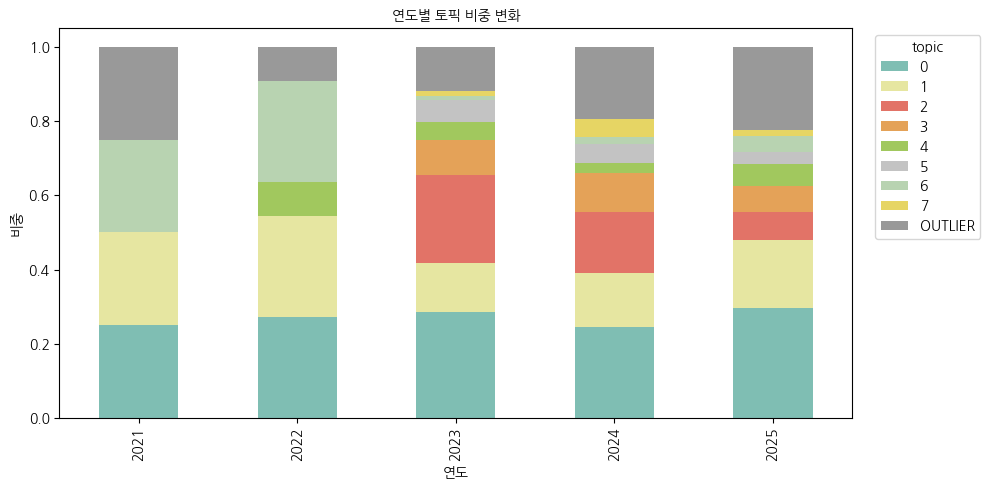

In [58]:
df_plot = df_gen.copy()

# TopK 아닌 건 OTHER로
df_plot["topic_id2"] = df_plot["topic_id"].where(df_plot["topic_id"].isin(top_topics), other="OTHER")
# outlier는 별도 표기
df_plot.loc[df_plot["topic_id"] == -1, "topic_id2"] = "OUTLIER"

ct = pd.crosstab(df_plot["year"], df_plot["topic_id2"], normalize="index").sort_index()

# 컬럼 순서 고정
ordered_cols = [t for t in top_topics if t in ct.columns]
for extra in ["OTHER", "OUTLIER"]:
    if extra in ct.columns:
        ordered_cols.append(extra)

ct_ordered = ct.reindex(columns=ordered_cols, fill_value=0)

# Matplotlib 색상 리스트(컬럼 순서와 1:1)
mat_colors = [topic_color_map_mpl.get(c, (0.85,0.85,0.85,1.0)) for c in ct_ordered.columns]

ax = ct_ordered.plot(
    kind="bar",
    stacked=True,
    color=mat_colors,
    figsize=(10, 5)
)

plt.xlabel("연도", fontproperties=font_prop)
plt.ylabel("비중", fontproperties=font_prop)
plt.title(f"연도별 토픽 비중 변화", fontproperties=font_prop)
plt.legend(
    title="topic",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    prop=font_prop,
    title_fontproperties=font_prop
)
for lab in ax.get_xticklabels() + ax.get_yticklabels():
    lab.set_fontproperties(font_prop)

plt.tight_layout()
plt.show()

In [70]:
# docs와 df_gen 인덱스 정렬
df_bt = df_gen.reset_index(drop=True).copy()

# BERTopic 문서-토픽 정보
doc_info = topic_model.get_document_info(docs).copy()
doc_info["doc_idx"] = doc_info.index

# 필요한 메타데이터만 결합
meta_cols = [c for c in ["NODE_ID", "NODE_TTLE"] if c in df_bt.columns]
df_join = doc_info.merge(
    df_bt[meta_cols].assign(doc_idx=df_bt.index),
    on="doc_idx",
    how="left"
)

# outlier 제외 + 토픽별 확률 상위 2개
df_rep2 = (
    df_join[df_join["Topic"] != -1]
    .sort_values(["Topic", "Probability"], ascending=[True, False])
    .groupby("Topic", as_index=False)
    .head(2)
)

# 발표/보고서용 최소 컬럼만 남기기
df_rep2_view = df_rep2[["Topic", "NODE_ID", "NODE_TTLE"]].reset_index(drop=True)

display(df_rep2_view)

,Topic,NODE_ID,NODE_TTLE
0,0,NODE11933396,한국어 대규모 언어 모델의 양자화 성능에 대한 비교 연구
1,0,NODE12263456,안전하고 유용한 전장 상황 분석 RAG 시스템을 위한 sLLM 선호도 학습 기법
2,1,NODE11725999,고압수용가 구내 비접지 배전계통의 1선지락 검출을 위한 계전기 정정 가이드라인
3,1,NODE12318931,Softmax 연산 가속을 위한 Tensor Core 구조 설계
4,2,NODE12434534,생성형 AI 시나리오의 주제어 및 서사적 특성 분석: TF-IDF와 의미망 시각화를...
5,2,NODE11557955,생성형 인공지능 기술의 핵심 구성 요소 기반 주요 특허 발굴 방법에 관한 연구
6,3,NODE11910212,초·중등 수업에서 생성형 AI 활용을 위한 콘텐츠 개발 연구
7,3,NODE11507119,생성형 AI를 활용한 문헌정보학 수업 설계에 대한 탐험적 연구
8,4,NODE12263459,문서 구조의 복잡도에 따른 문서 OCR이 RAG 성능에 미친 영향 분석
9,4,NODE12285660,자동차 데이터 플랫폼: 자동차 산업 데이터를 활용한 RAG 시스템 구축을 위한 Re...


In [60]:
df_plot = df_gen.copy()

# TopK 아닌 건 OTHER / outlier는 OUTLIER
df_plot["topic_id2"] = df_plot["topic_id"].where(df_plot["topic_id"].isin(top_topics), other="OTHER")
df_plot.loc[df_plot["topic_id"] == -1, "topic_id2"] = "OUTLIER"

# 기간(전/후): 2021-2022 vs 2023-2025
df_plot = df_plot[df_plot["year"].between(2021, 2025)].copy()

df_plot["period"] = np.where(
    df_plot["year"].between(2021, 2022),
    "2021-2022",
    "2023-2025"
)

# period별 토픽 비중 (행 합=1)
pt = pd.crosstab(df_plot["period"], df_plot["topic_id2"], normalize="index")

# 컬럼 순서: top_topics(있으면) + OTHER/OUTLIER
ordered_cols = [t for t in top_topics if t in pt.columns]
for extra in ["OTHER", "OUTLIER"]:
    if extra in pt.columns:
        ordered_cols.append(extra)

pt = pt.reindex(columns=ordered_cols, fill_value=0.0)

# 전/후 변화량 (post - pre)
delta = (pt.loc["2023-2025"] - pt.loc["2021-2022"]).sort_values(ascending=False)

print("=== Period share (2021-2022 vs 2023-2025) ===")
display(pt)

print("=== Delta (2023-2025 minus 2021-2022) ===")
display(delta.to_frame("delta_share"))

=== Period share (2021-2022 vs 2023-2025) ===


topic_id2,0,1,2,3,4,5,6,7,OUTLIER
period,,,,,,,,,
2021-2022,0.266667,0.266667,0.000000,0.000000,0.066667,0.000000,0.266667,0.000000,0.133333
2023-2025,0.277154,0.163546,0.124844,0.084894,0.046192,0.042447,0.031211,0.027466,0.202247


=== Delta (2023-2025 minus 2021-2022) ===


,delta_share
topic_id2,
2,0.124844
3,0.084894
OUTLIER,0.068914
5,0.042447
7,0.027466
0,0.010487
4,-0.020474
1,-0.103121
6,-0.235456


In [66]:
TOPN = 10

delta_df = delta.reset_index()
delta_df.columns = ["topic_id2", "delta_share"]

# 증가 TOP / 감소 TOP
inc_top = delta_df.head(TOPN).copy()
dec_top = delta_df.tail(TOPN).copy()

print("=== 토픽들 (Top) ===") # 지금 전체 10개 미만이라 그냥 하나 inc_top으로만 뽑아도 다 보임
display(inc_top)

# 확인용으로 저장
pt.to_csv("BERTopic_period_share_2021-2022_vs_2023-2025.csv", encoding="utf-8-sig")
delta_df.to_csv("BERTopic_period_delta_2023-2025_minus_2021-2022.csv", encoding="utf-8-sig", index=False)

=== 토픽들 (Top) ===


,topic_id2,delta_share
0,2,0.124844
1,3,0.084894
2,OUTLIER,0.068914
3,5,0.042447
4,7,0.027466
5,0,0.010487
6,4,-0.020474
7,1,-0.103121
8,6,-0.235456


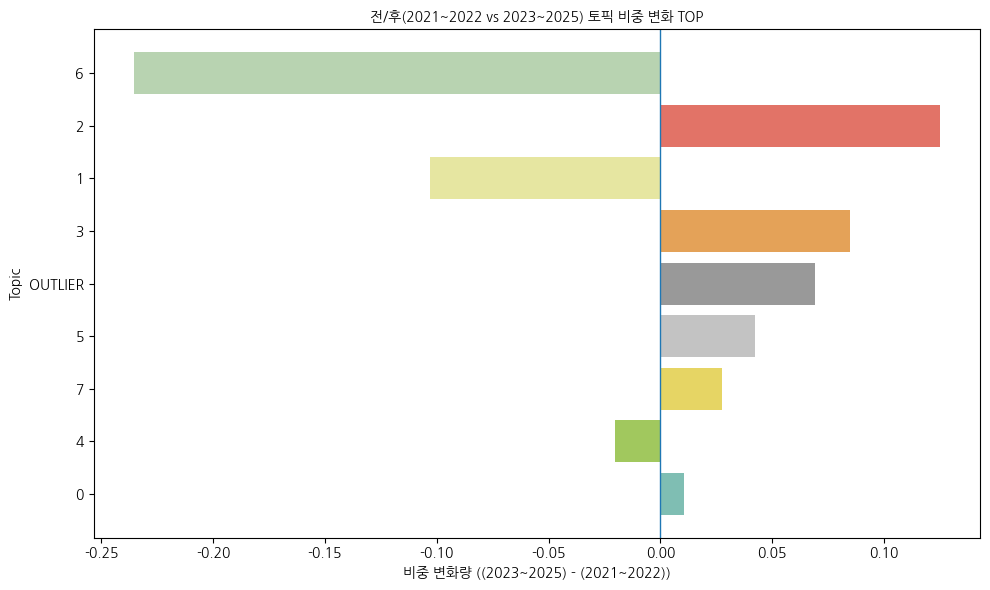

In [62]:
# 절대값 변화가 큰 토픽만 뽑아서 시각화
TOPM = 15
delta_abs = delta.reindex(pt.columns).copy()
delta_abs = delta_abs.reindex(delta_abs.abs().sort_values(ascending=False).head(TOPM).index)

# 색상(기존 topic_color_map_mpl 재사용)
bar_colors = [topic_color_map_mpl.get(t, (0.6, 0.6, 0.6, 1.0)) for t in delta_abs.index]

plt.figure(figsize=(10, 6))
plt.barh(delta_abs.index.astype(str), delta_abs.values, color=bar_colors)
plt.axvline(0, linewidth=1)
plt.xlabel("비중 변화량 ((2023~2025) - (2021~2022))", fontproperties=font_prop)
plt.ylabel("Topic", fontproperties=font_prop)
plt.title("전/후(2021~2022 vs 2023~2025) 토픽 비중 변화 TOP", fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()